Explain code:

https://chatgpt.com/c/68e446dc-4524-8331-b2ea-05b2bd2b5cda

In [1]:
# https://www.kaggle.com/shivamkushwaha/bbc-full-text-document-classification
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2025-10-06 22:44:41--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  --.-KB/s    in 0.1s    

2025-10-06 22:44:42 (44.2 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

In [3]:
df = pd.read_csv('bbc_text_cls.csv')
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [4]:
# map classes to integers from 0 ... K-1
df['labels'].astype("category").cat.codes

,0
0,0
1,0
2,0
3,0
4,0
...,...
2220,4
2221,4
2222,4
2223,4


In [5]:
df['target']= df['labels'].astype("category").cat.codes

In [6]:
df_train, df_test = train_test_split(df, test_size = 0.3)

In [7]:
tfidf = TfidfVectorizer(stop_words='english')
Xtrain = tfidf.fit_transform(df_train['text'])
Xtest = tfidf.transform(df_test['text'])

In [8]:
Ytrain = df_train['target']
Ytest = df_test['target']

In [9]:
# number of classes
K = df['target'].max()+1
K

np.int8(5)

In [11]:
# input dimensions
D =Xtrain.shape[1]

In [12]:
# build model
i = Input(shape=(D,))
x = Dense(300, activation='relu')(i) # 300 hidden units
x = Dense(K)(x) # softmax included in loss

model = Model(i, x)

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25407)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     7,622,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,623,905 (29.08 MB)

 Trainable params: 7,623,905 (29.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = 'adam' ,
    metrics = ['accuracy']
)

In [16]:
# data must not be sparse matrix before passing into tensorflow
Xtrain = Xtrain.toarray()
Xtest = Xtest.toarray()

In [17]:
r = model.fit(
  Xtrain, Ytrain,
  validation_data=(Xtest, Ytest),
  epochs=7,
  batch_size=128,
)

Epoch 1/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.6826 - loss: 1.5352 - val_accuracy: 0.9671 - val_loss: 1.1860
Epoch 2/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.9941 - loss: 1.0003 - val_accuracy: 0.9760 - val_loss: 0.7171
Epoch 3/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.9972 - loss: 0.5046 - val_accuracy: 0.9760 - val_loss: 0.4053
Epoch 4/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.9977 - loss: 0.2203 - val_accuracy: 0.9775 - val_loss: 0.2586
Epoch 5/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.9993 - loss: 0.1026 - val_accuracy: 0.9775 - val_loss: 0.1933
Epoch 6/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 297ms/step - accuracy: 1.0000 - loss: 0.0571 - val_accuracy: 0.9790 - val_loss: 0.1622
Epoch 7/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 1.0000 - loss: 0.0363 - val_accuracy: 0.9805 - val_loss: 0.1438


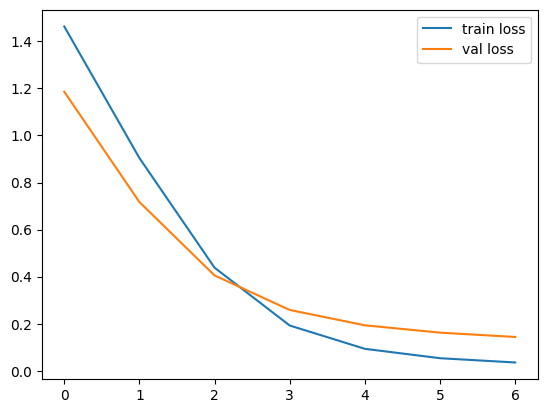

In [18]:
# Plot loss per iteration (epoch)
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend();

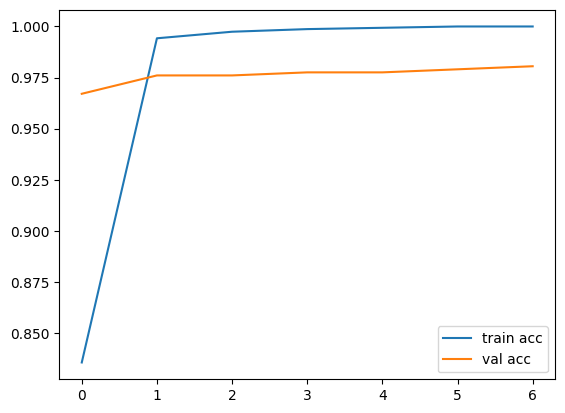

In [19]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend();

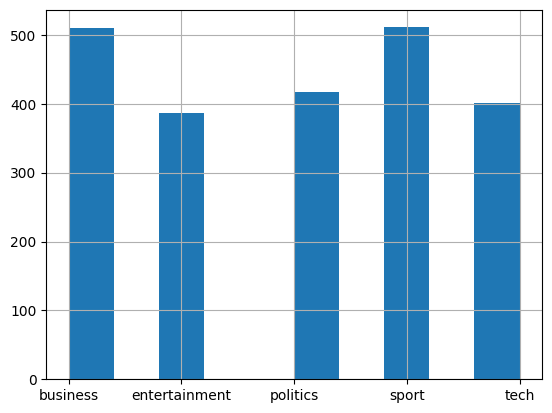

In [20]:
df['labels'].hist();